# IN5148: Estadística y Ciencia de Datos Aplicadas a la Ingeniería

## Examen Final – FJ 2025

**Nombre**: William Frank Monroy Mamani

**Matrícula**: A00829796

**Link to Google Github**:

**Nota**: El uso de Gemini solo está permitido para generar código. No está permitido para generar respuestas o interpretaciones a las preguntas.

In [39]:
!pip3 install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

## Problema 1

La compañía eléctrica Pacific está interesada en conocer su posicionamiento en comparación a sus competidores. Para esto, la compañía recolectó datos sobre otras 21 compañías eléctricas en Estados Unidos. Los datos incluyen valores de seis predictores:

* Tasa: Tasa de rendimiento de capital
* Kilowatt: Costo por kilowatt en centavos de dólar
* Carga: Factor de carga anual
* Ventas: Ventas en miles de dólares
* Energia: Porcentaje de energía nuclear
* Costo: Costo total de combustible en dólares

Los datos de las compañías están el archivo “Compania_Electrica.xlsx”. El objetivo de la compañía es saber si sus competidores (junto con ella) pueden ser incluidos en grupos con características similares.

Carga los datos en el siguiente bloque de código.

In [41]:
data = pd.read_excel("Compania_Electrica.xlsx")
data.head()

,Compania,Tasa,Kilowatt,Carga,Ventas,Energia,Costo
0,Arizona,9.2,151,54.4,9077,0.0,0.628
1,Boston,10.3,202,57.9,5088,25.3,1.555
2,Central,15.4,113,53.0,9212,0.0,1.058
3,Commonwealth,11.2,168,56.0,6423,34.3,0.700
4,NY,8.8,192,51.2,3300,15.6,2.044


In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Compania  22 non-null     object 
 1   Tasa      22 non-null     float64
 2   Kilowatt  22 non-null     int64  
 3   Carga     22 non-null     float64
 4   Ventas    22 non-null     int64  
 5   Energia   22 non-null     float64
 6   Costo     22 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 1.3+ KB


a)	Aplica la técnica de agrupamiento jerárquico con un enlace completo (i.e., *complete linkage*) para detectar cuatro grupos de compañías. Muestra el dendrograma señalando el agrupamiento requerido. (10 pts)

In [43]:
# Inserta tu código aquí
X_company = data.filter(["Tasa", "Kilowatt", "Carga","Ventas","Energia","Costo"])
X_company.head()

,Tasa,Kilowatt,Carga,Ventas,Energia,Costo
0,9.2,151,54.4,9077,0.0,0.628
1,10.3,202,57.9,5088,25.3,1.555
2,15.4,113,53.0,9212,0.0,1.058
3,11.2,168,56.0,6423,34.3,0.700
4,8.8,192,51.2,3300,15.6,2.044


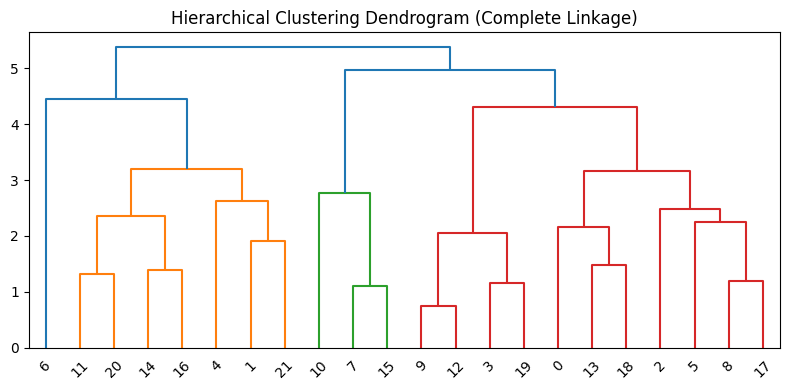

In [44]:
scaler = StandardScaler()
predictores_scaled = scaler.fit_transform(X_company)

Clust_Company = linkage(predictores_scaled, method = 'complete')

num_clusters = 4
distance_threshold = Clust_Company[-(num_clusters - 1), 2]

plt.figure(figsize=(8, 4))
dendrogram(Clust_Company, color_threshold=distance_threshold)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.tight_layout()
plt.show()

In [ ]:
company_clusters = fcluster(Clust_Company, t=num_clusters, criterion='maxclust')

X_company_clust = (
    X_company.assign(Clusters=company_clusters)
)

X_company_clust.head(4)

,Tasa,Kilowatt,Carga,Ventas,Energia,Costo,Clusters
0,9.2,151,54.4,9077,0.0,0.628,4
1,10.3,202,57.9,5088,25.3,1.555,1
2,15.4,113,53.0,9212,0.0,1.058,4
3,11.2,168,56.0,6423,34.3,0.700,4


b)	Para cada grupo, calcula el valor promedio de las ventas y costo por Kilowatt.  (10 pts)

In [ ]:
resumen_grupos = (
    X_company_clust.groupby("Clusters")[["Ventas", "Kilowatt"]]
    .mean()
    .sort_index()
)

print(resumen_grupos.round(2))

            Ventas  Kilowatt
Clusters                    
1          6209.57    178.57
2          7642.00    175.00
3         15504.67    223.33
4          8953.27    145.91


c)	Con base en los resultados del punto anterior, compara y comenta el desempeño de las compañías en términos del promedio de las ventas y el costo promedio por Kilowatt.  (10 pts)

Con base al resultado podemos decir que el top de clusters o empresas que tienen mejor venta son:
1. Cluster 3
2. Cluster 1
3. Cluster 2
4. Cluster 4

Y el cuanto al consumo de kilowatt, el orden es:

1. Cluster 3
2. Cluster 1
3. Cluster 2
4. Cluster 4

Con lo que podemos concluir que el cluster 3 es el mejor en ambos aspectos, mientras que el cluster 4 es el peor.

## Problema 2

En 2005, la Administración Federal de Carreteras midió el consumo de gasolina en los 50 estados y el Distrito de Columbia de Estados Unidos. La variable de respuesta $Y$ representa el consumo de galones de gasolina por habitante de 16 años o más. Considere las siguientes cuatro variables predictoras:

* x1: Impuesto estatal a la gasolina (centavos por galón)
* x2: Ingreso per cápita (en miles de dólares)
* x3: Carreteras pavimentadas (en cientos de millas)
* x4: Conductores con licencia por cada 1000 personas de 16 años o más (este porcentaje supera los 1000 en algunos estados, ya que los permisos de aprendizaje se consideran licencias y los titulares de permisos de aprendizaje pueden ser menores de 16 años).

Los datos se encuentran en el archivo de Excel "Consumo_Gasolina.xlsx".

Cargue los datos y responda las preguntas a continuación.

In [46]:
data = pd.read_excel("Consumo_Gasolina.xlsx")
X_full = data.filter(["X1","X2","X3", "X4"])
Y_full = data.filter(["Y"])

a) Ajusta un modelo de regresión lineal múltiple que explica la respuesta en términos de los predictores. ¿Cuáles predictores son significativos de acuerdo con la hipótesis $H_0: \beta_j=0$ contra $H_1: \beta_j \neq 0$? Usa $\alpha = 0.05$ y justifica tu respuesta. (10 pts)

In [47]:
scaler = StandardScaler()
predictores_scaled = scaler.fit_transform(X_full)

LRmodel = LinearRegression()
LRmodel.fit(X_full, Y_full)
print("Intercept:", LRmodel.intercept_)
print("Coefficients:", LRmodel.coef_)


Intercept: [439.97432647]
Coefficients: [[-6.29269379 -6.1717964   0.27661884  0.52098788]]


In [48]:
auto_X_train_with_intercept = sm.add_constant(X_full)
# Create linear regression object in statsmodel
regr = sm.OLS(Y_full, auto_X_train_with_intercept)

# Train the model using the training sets
linear_model = regr.fit()

model_summary = linear_model.summary()
print(model_summary)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     11.66
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.28e-06
Time:                        20:11:22   Log-Likelihood:                -281.28
No. Observations:                  51   AIC:                             572.6
Df Residuals:                      46   BIC:                             582.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        439.9743    171.834      2.560      0.0

Respuesta a la pregunta con justificación

A partir de la tabla podemos notar que los predictores significativos son x1, x2 y x4. El predictor x3 no es significativo ya que tiene un p-value mayor a 0.05, lo que sugiere que la cantidad de carreteras pavimentadas no tiene un impacto estadísticamente significativo en el consumo de gasolina por habitante.

b) Interpreta los coeficientes estimados de los predictores significativos. (10 pts)

Habiendo ya descartado el predictor x3 por no ser significativo, podemos interpretar los coeficientes de los predictores significativos de la siguiente manera:
* x1: Por cada aumento de un centavo en el impuesto estatal a la gasolina, el consumo de gasolina por habitante disminuira en 6.29 galones.
* x2: Por cada aumento de mil dólares en el ingreso per cápita, el consumo de gasolina por habitante disminuira en 6.17 galones.
* x4: Por cada aumento de un conductor con licencia por cada 1000 personas de 16 años o más, el consumo de gasolina por habitante aumentara en 0.52 galones.

c) Usando validación cruzada con 5 pliegues, evalua el rendimiento del modelo en términos de la raíz cuadrada del error cuadreatico medio de predicción. Es decir, aplica 5-fold cross validation para estimar el root mean squared error. (10 pts)

In [59]:
LRmodel_cv = LinearRegression()

neg_cv_MSEs = cross_val_score(LRmodel_cv, X_full, Y_full, cv = 5, 
                        scoring = "neg_mean_squared_error")
print(neg_cv_MSEs)
cv_MSEs = -neg_cv_MSEs



[-4426.27321096 -7593.76830576 -5687.83849731 -3627.89596687
 -4763.49560048]


In [58]:
MSE_cv = cv_MSEs.mean()
print(round(MSE_cv, 3))

5219.854


In [57]:
cv_RMSEs = np.sqrt(cv_MSEs)
RMSE_cv = cv_RMSEs.mean()
print(round(RMSE_cv, 3))

71.668


d) Predice el consumo de galones de gasolina por habitante de 16 años o más si un estado tuviera un X1 = 19, X2 = 90, X3 = 1000, y X4 = 700. (10 pts)

In [67]:
nuevo_estado = pd.DataFrame({
    "X1": [19],
    "X2": [90],
    "X3": [1000],
    "X4": [700]
})

prediccion_Y = LRmodel.predict(nuevo_estado)
print(round(float(prediccion_Y[0][0]), 2))

406.26
